## Completing coastlines

In [1]:
import json
import os
import time

os.chdir("../../..")

from tests.notebooks.graph_ingestion.neo4j_client import Neo4jClient

graph_client = Neo4jClient()

In [2]:
with open("raw_maps/seamarks_and_coastlines_solent.geojson") as map:
    raw_map = json.load(map)

features = raw_map["features"]
coastline_count = 0
for feature in features:  
    # Coastline geoms
    try:
        if feature["properties"]["natural"] == "coastline":
            graph_client.injest_coastline(feature)
            coastline_count += 1
    except KeyError:
        pass


In [3]:
import geopandas as gpd
from shapely import line_merge, unary_union, Polygon, LineString, reverse
from shapely import polygonize
from shapely.ops import snap
from shapely.geometry import box
from shapely.validation import make_valid

PROJECTED_CRS = "EPSG:27700"
OUTPUT_CRS = "EPSG:4326"
BBOX_BUFFER = 100 # Meters
SNAP_TOLERANCE = 10 # Meters

gdf = gpd.read_file("raw_maps/seamarks_and_coastlines_solent.geojson")

##### Extract only coastline data

In [4]:
coastlines = gdf[gdf["natural"]=="coastline"]
coastlines = coastlines.to_crs(PROJECTED_CRS) # TODO: change this later

##### Combine coastlines:

nb - to export an image of the coastlines...
```python
combined_coastlines
```

In [5]:
combined = unary_union(coastlines.geometry)
combined_coastline = line_merge(combined)

##### snap lines
 - Snapped is one geometry at the moment which seems strange - islands + mainland coastline
 - run time seems to be cached ~ 1 min 41s

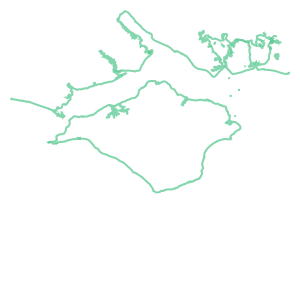

In [6]:
snapped = snap(combined_coastline, combined_coastline, SNAP_TOLERANCE)
snapped

### Apply bounding box

In [7]:
polygons = list(polygonize([snapped.geoms]))

land_polys = gpd.GeoSeries([poly for poly in polygons], crs=PROJECTED_CRS)
land_polys = land_polys.apply(make_valid)

minx, miny, maxx, maxy = land_polys.total_bounds
bbox = box(
    minx,
    miny,
    maxx,
    maxy + BBOX_BUFFER
)

land_union = unary_union(list(land_polys))
sea_geom = bbox.difference(land_union)

# Build GeoDataFrames
land_gdf = gpd.GeoDataFrame(geometry=land_polys, crs=PROJECTED_CRS)
sea_gdf = gpd.GeoDataFrame(geometry=[sea_geom], crs=PROJECTED_CRS)

# Reproject results back to WGS84
land_gdf = land_gdf.to_crs(OUTPUT_CRS)
sea_gdf = sea_gdf.to_crs(OUTPUT_CRS)

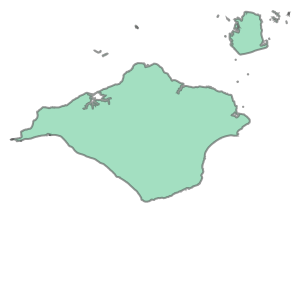

In [8]:
land_union

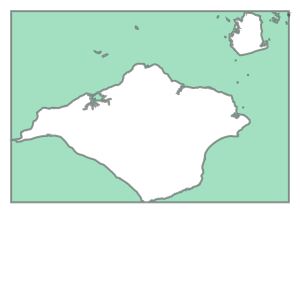

In [9]:
sea_geom

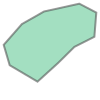

In [10]:
land_union.geoms[0]

---
### Processing the upper coastline with a bounding box

In [11]:
import pandas as pd

mainland_coastline = snapped.geoms[0]
bounds = mainland_coastline.bounds

bbox = box(bounds[0], bounds[1], bounds[2], bounds[3]+BBOX_BUFFER)
bbox_boundary = bbox.boundary
bbox_coords = list(bbox.exterior.coords)
print("Bounding box coordinates")
print(f"--- Bottom left: {bbox_coords[0]}")
print(f"--- Top Left: {bbox_coords[1]}")
print(f"--- Top Right: {bbox_coords[2]}")
print(f"--- Bottom Right: {bbox_coords[3]}")

print("For the mainland")
print(f"--- Left: {mainland_coastline.coords[0]}")
print(f"--- Right: {mainland_coastline.coords[-1]}")


Bounding box coordinates
--- Bottom left: (472813.3993368532, 89690.604925364)
--- Top Left: (472813.3993368532, 110141.74556015746)
--- Top Right: (421792.6594035358, 110141.74556015746)
--- Bottom Right: (421792.6594035358, 89690.604925364)
For the mainland
--- Left: (421792.6594035358, 93133.4270406347)
--- Right: (472813.3993368532, 105130.9923299462)


In [12]:
# New polygon
top_edge = LineString([bbox_coords[2], bbox_coords[1]])
right_edge = LineString([bbox_coords[1], mainland_coastline.coords[-1]])
left_edge = LineString([mainland_coastline.coords[0], bbox_coords[2]])

top_edge = snap(top_edge, left_edge, 10)
top_edge = snap(top_edge, right_edge, 10)
mainland_coastline = snap(mainland_coastline, right_edge, 10)
mainland_coastline = snap(mainland_coastline, left_edge, 10)

reversed_mainland = reverse(mainland_coastline)

lines = [
    top_edge,
    right_edge,
    mainland_coastline, # Bottom edge - the coastline
    left_edge
]

merged = unary_union(lines)
polygons = polygonize([merged])
mainland_polygon = polygons
print(f"top edge == right edge: {top_edge.coords[-1] == right_edge.coords[0]}") 
print(f"right edge == mainland edge: {right_edge.coords[-1] == reversed_mainland.coords[0]}")
print(f"mainland edge == left edge {reversed_mainland.coords[-1] == left_edge.coords[0]}")
print(f"left edge == top edge: {left_edge.coords[-1] == top_edge.coords[0]}")

top edge == right edge: True
right edge == mainland edge: True
mainland edge == left edge True
left edge == top edge: True


In [13]:
from shapely import get_geometry

get_geometry(polygons,10)
list(polygons.geoms)

[<POLYGON ((421792.659 110141.746, 472813.399 110141.746, 472813.399 105130.9...>,
 <POLYGON ((471833.034 104429.009, 471838.702 104422.206, 471838.66 104420.69...>]

In [14]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(geometry=list(polygons.geoms), crs=PROJECTED_CRS)


---
### Exploring the islands and other linestrings

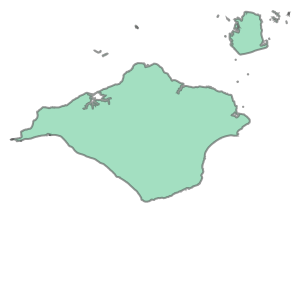

In [15]:
land_union

In [16]:
sorted_polygons = sorted(land_union.geoms, key=lambda g: g.area, reverse=True)
[ geom.area for geom in list(sorted_polygons) if geom.exterior.is_ring]

[381332557.3559528,
 24506221.10756068,
 306554.29109148344,
 73648.4312199176,
 69877.619370185,
 66171.66926613102,
 44065.74336944721,
 36681.194725804104,
 25883.829834121876,
 17169.686572508726,
 16117.022775528189,
 12331.445859109954,
 12002.060536186515,
 8283.022737715688,
 4747.859078514286,
 3478.5567161879676,
 2795.798538242098,
 1938.345287219377,
 1589.0994009887086,
 1304.4179984791929,
 1019.4002269852765,
 989.4462672201537,
 908.360912955681,
 827.3430381453279,
 672.3811312826774,
 657.0926393802739,
 583.3439370617714,
 557.3507901111452,
 551.4727193676584,
 315.6685762907721,
 197.40720013490164,
 97.51446366620652]

In [17]:
islands = gpd.GeoDataFrame(geometry=list(land_union.geoms), crs = PROJECTED_CRS)

---

### Export the processed land features

In [18]:
gdf = gpd.pd.concat([gdf, islands], ignore_index=True)
gdf = gdf.to_crs(OUTPUT_CRS)
gdf.to_file("polygons.geojson", driver="GeoJSON")